In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


In [2]:
dir = os.getcwd()

# Feature extraction

In [3]:
data = pd.read_excel( f"{dir}/DMT Questionnaires and Subject data.xlsx",
                     sheet_name = "Subject data",
                     skiprows = [3, 6, 9, 14, 17, 24, 32],
                     index_col = False )
data.loc[data['DMT - Previous Experiences'] == 1, ['DMT - Previous Experiences']] = 0
data.loc[data['DMT - Previous Experiences'] > 1, ['DMT - Previous Experiences']] = 1
dmt_exp = data["DMT - Previous Experiences"]

In [4]:
display( data.head() )

,Subject,Age,Weight (kg),Male(0) / Female(1),Ayahuasca - Previous Experiences,DMT - Previous Experiences
0,S1,37,69.0,0,NaN,1
1,S2,35,115.0,0,NaN,1
2,S4,31,51.0,1,NaN,1
3,S5,32,78.0,0,NaN,1
4,S7,33,55.0,1,NaN,0


Read precalculated PSD and calculate averge value per band and subject

In [5]:
aal90_labels = pd.read_csv( f"{dir}/PSD/AAL90.csv", delimiter = ";", index_col = 0 )["Label"].to_list()
pre_alpha = pd.read_csv( f"{dir}/PSD/alpha.csv", names = aal90_labels, skiprows=[10] )
pre_beta = pd.read_csv( f"{dir}/PSD/beta.csv", names = aal90_labels, skiprows=[10] )
pre_delta = pd.read_csv( f"{dir}/PSD/delta.csv", names = aal90_labels, skiprows=[10] )
pre_gamma1 = pd.read_csv( f"{dir}/PSD/gamma1.csv", names = aal90_labels, skiprows=[10] )
pre_gamma2 = pd.read_csv( f"{dir}/PSD/gamma2.csv", names = aal90_labels, skiprows=[10] )
pre_theta = pd.read_csv( f"{dir}/PSD/theta.csv", names = aal90_labels, skiprows=[10] )
dmt_alpha = pd.read_csv( f"{dir}/PSD/DMT_alpha.csv", names = aal90_labels, skiprows=[10] )
dmt_beta = pd.read_csv( f"{dir}/PSD/DMT_beta.csv", names = aal90_labels, skiprows=[10] )
dmt_delta = pd.read_csv( f"{dir}/PSD/DMT_delta.csv", names = aal90_labels, skiprows=[10] )
dmt_gamma1 = pd.read_csv( f"{dir}/PSD/DMT_gamma1.csv", names = aal90_labels, skiprows=[10] )
dmt_gamma2 = pd.read_csv( f"{dir}/PSD/DMT_gamma2.csv", names = aal90_labels, skiprows=[10] )
dmt_theta = pd.read_csv( f"{dir}/PSD/DMT_theta.csv", names = aal90_labels, skiprows=[10] )

In [6]:
pre_alpha_m = pre_alpha.mean( axis=1 ).round( 3 )
pre_beta_m = pre_beta.mean( axis=1 ).round( 3 )
pre_delta_m = pre_delta.mean( axis=1 ).round( 3 )
pre_gamma1_m = pre_gamma1.mean( axis=1 ).round( 3 )
pre_gamma2_m = pre_gamma2.mean( axis=1 ).round( 3 )
pre_theta_m = pre_theta.mean( axis=1 ).round( 3 )
dmt_alpha_m = dmt_alpha.mean( axis=1 ).round( 3 )
dmt_beta_m = dmt_beta.mean( axis=1 ).round( 3 )
dmt_delta_m = dmt_delta.mean( axis=1 ).round( 3 )
dmt_gamma1_m = dmt_gamma1.mean( axis=1 ).round( 3 )
dmt_gamma2_m = dmt_gamma2.mean( axis=1 ).round( 3 )
dmt_theta_m = dmt_theta.mean( axis=1 ).round( 3 )

Functional connectivity: coherence

In [16]:
import mne
import scipy

eeg_data = {}

for i in range( 1, 36 ):
    if i not in [3, 6, 9, 14, 17, 24, 32]:
        if i in range( 1, 10 ):
            eeg_data[f'S0{i}'] = mne.read_epochs_eeglab( f"{dir}/CleanEEG/S0{i}_DMT_ICA_pruned.set", verbose=False )
        else:
            eeg_data[f'S{i}'] = mne.read_epochs_eeglab( f"{dir}/CleanEEG/S{i}_DMT_ICA_pruned.set", verbose=False )


C:\Users\u528488\AppData\Local\Temp\ipykernel_8000\3623589820.py:9: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  eeg_data[f'S0{i}'] = mne.read_epochs_eeglab( f"{dir}/CleanEEG/S0{i}_DMT_ICA_pruned.set", verbose=False )
C:\Users\u528488\AppData\Local\Temp\ipykernel_8000\3623589820.py:9: RuntimeWarning: Data file name in EEG.data (S01-DMT_ICA_pruned.fdt) is incorrect, the file name must have changed on disk, using the correct file name (S01_DMT_ICA_pruned.fdt).
  eeg_data[f'S0{i}'] = mne.read_epochs_eeglab( f"{dir}/CleanEEG/S0{i}_DMT_ICA_pruned.set", verbose=False )
C:\Users\u528488\AppData\Local\Temp\ipykernel_8000\3623589820.py:9: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  eeg_data[f'S0{i}'] = mne.read_epochs_eeglab( f"{dir}/CleanEEG/S0{i}_DMT_ICA_pruned.set", verbose=False )
C:\Users\u528488\AppData\Local\Temp\ipykernel_8000\3623589820.py:9: RuntimeWar

In [12]:
for data in eeg_data:
    print( np.shape( eeg_data[data] ) )

print()
print( type( eeg_data['S01'] ) )

(210, 24, 1000)
(172, 24, 1000)
(227, 24, 1000)
(119, 24, 1000)
(134, 24, 1000)
(157, 24, 1000)
(104, 24, 1000)
(108, 24, 1000)
(149, 24, 1000)
(150, 24, 1000)
(272, 24, 1000)
(228, 24, 1000)
(254, 24, 1000)
(137, 24, 1000)
(192, 24, 1000)
(190, 24, 1000)
(226, 24, 1000)
(239, 24, 1000)
(125, 24, 1000)
(160, 24, 1000)
(164, 24, 1000)
(173, 24, 1000)
(155, 24, 1000)
(191, 24, 1000)
(160, 24, 1000)
(172, 24, 1000)
(168, 24, 1000)
(226, 24, 1000)

<class 'mne.io.eeglab.eeglab.EpochsEEGLAB'>


In [17]:
# Compute channeal coherence
from mne_connectivity import spectral_connectivity_epochs

def compute_coherence( data, f_min, f_max ):
    coh = spectral_connectivity_epochs( data, 
                                       method = 'imcoh',
                                       mode = 'multitaper', 
                                       fmin = f_min, 
                                       fmax = f_max, 
                                       faverage = True,
                                       mt_adaptive = True,
                                       verbose=False
                                       )
    return coh

In [18]:
channel_coherence = {}
bands = {"delta": (1., 4.),
         "theta": (4., 8.),
         "alpha": (8., 12.),
         "beta": (12., 30.),
         "gamma1": (30., 40.),
         "gamma2": (40., 70.)
         }

for subject in eeg_data:
    channel_coherence[subject] = {}
    for band in bands:
        coh = compute_coherence( eeg_data[subject], bands[band][0], bands[band][1] )
        channel_coherence[subject][band] = coh

C:\Users\u528488\AppData\Local\Temp\ipykernel_8000\757177958.py:5: RuntimeWarning: There were no Annotations stored in <EpochsEEGLAB | 210 events (all good), 0 – 1.998 s (baseline off), ~38.5 MiB, data loaded,
 'X/X': 209
 'X': 1>, so metadata was not modified.
  coh = spectral_connectivity_epochs( data,
C:\Users\u528488\AppData\Local\Temp\ipykernel_8000\757177958.py:5: RuntimeWarning: fmin=1.000 Hz corresponds to 2.000 < 5 cycles based on the epoch length 2.000 sec, need at least 5.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  coh = spectral_connectivity_epochs( data,
C:\Users\u528488\AppData\Local\Temp\ipykernel_8000\757177958.py:5: RuntimeWarning: There were no Annotations stored in <EpochsEEGLAB | 210 events (all good), 0 – 1.998 s (baseline off), ~38.5 MiB, data loaded,
 'X/X': 209
 'X': 1>, so metadata was not modified.
  coh = spectral_connectivity_epochs( data,
C:\Users\u528488\AppData\Local\Temp\ipykernel_8000\757177958.py:5: RuntimeWarning: There were 

In [22]:
print( channel_coherence['S01'])

{'delta': <SpectralConnectivity | freq : [2.500000, 2.500000], , nave : 210, nodes, n_estimated : 24, 576, ~41 KiB>, 'theta': <SpectralConnectivity | freq : [6.000000, 6.000000], , nave : 210, nodes, n_estimated : 24, 576, ~41 KiB>, 'alpha': <SpectralConnectivity | freq : [10.000000, 10.000000], , nave : 210, nodes, n_estimated : 24, 576, ~41 KiB>, 'beta': <SpectralConnectivity | freq : [21.000000, 21.000000], , nave : 210, nodes, n_estimated : 24, 576, ~41 KiB>, 'gamma1': <SpectralConnectivity | freq : [35.000000, 35.000000], , nave : 210, nodes, n_estimated : 24, 576, ~41 KiB>, 'gamma2': <SpectralConnectivity | freq : [55.000000, 55.000000], , nave : 210, nodes, n_estimated : 24, 576, ~41 KiB>}


In [23]:
# s02 = eeg_data['S02'].get_data( picks = ['eeg'] )
# s02_coh = spectral_connectivity_epochs( eeg_data['S02'], 
#                                        method='imcoh', 
#                                        fmin= 1.,
#                                        fmax= 4.,
#                                        faverage=True )

# print(  np.squeeze( s02_coh.get_data( output = 'dense' ) ) )


In [71]:
regions = {
    'Fp1': 'Frontal_Sup_Medial_L',       # Left prefrontal cortex
    'Fp2': 'Frontal_Sup_Medial_R',       # Right prefrontal cortex
    'Fz': 'Frontal_Sup_Medial_L',        # Medial frontal cortex
    'F7': 'Frontal_Mid_L',               # Left lateral frontal cortex
    'F8': 'Frontal_Mid_R',               # Right lateral frontal cortex
    'FC1': 'Frontal_Sup_L',              # Left superior frontal cortex
    'FC2': 'Frontal_Sup_R',              # Right superior frontal cortex
    'Cz': 'Cingulum_Mid_L',              # Midline cingulate cortex
    'C3': 'Precentral_L',                # Left primary motor cortex
    'C4': 'Precentral_R',                # Right primary motor cortex
    'T7': 'Temporal_Sup_L',              # Left superior temporal gyrus
    'T8': 'Temporal_Sup_R',              # Right superior temporal gyrus
    'CPz': 'Cingulum_Post_L',            # Midline posterior cingulate cortex
    'CP1': 'Parietal_Sup_L',             # Left superior parietal lobule
    'CP2': 'Parietal_Sup_R',             # Right superior parietal lobule
    'CP5': 'SupraMarginal_L',            # Left supramarginal gyrus
    'CP6': 'SupraMarginal_R',            # Right supramarginal gyrus
    'TP9': 'Temporal_Inf_L',             # Left inferior temporal gyrus
    'TP10': 'Temporal_Inf_R',            # Right inferior temporal gyrus
    'Pz': 'Precuneus_L',                 # Medial parietal lobe (precuneus)
    'P3': 'Parietal_Inf_L',              # Left inferior parietal lobule
    'P4': 'Parietal_Inf_R',              # Right inferior parietal lobule
    'O1': 'Occipital_Inf_L',             # Left inferior occipital gyrus
    'O2': 'Occipital_Inf_R'              # Right inferior occipital gyrus
}



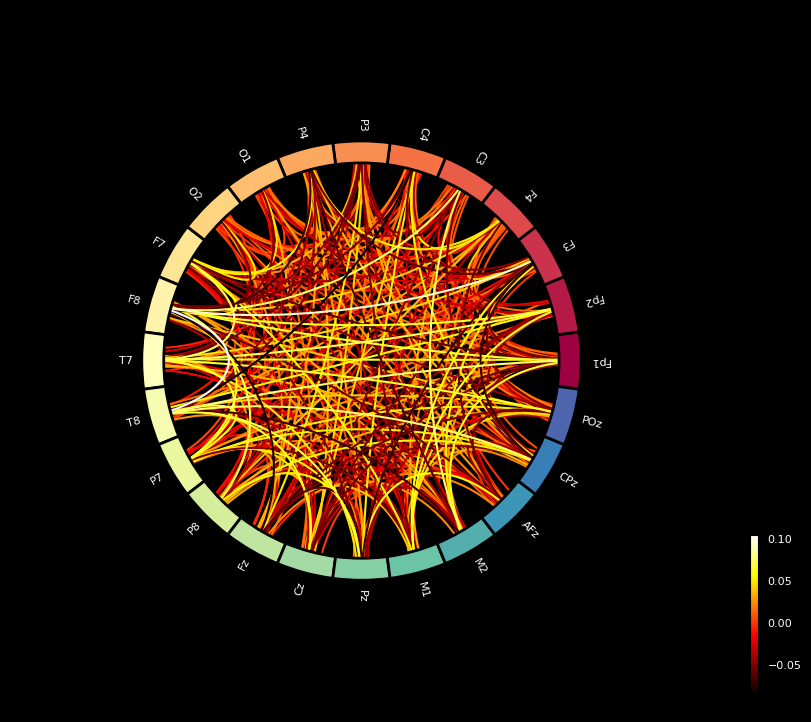

(<Figure size 800x800 with 2 Axes>, <PolarAxes: >)

In [210]:
from mne_connectivity.viz import plot_connectivity_circle

# plot_connectivity_circle( np.squeeze(s02_coh.get_data( output='dense')), eeg_data['S02'].ch_names )
# print( eeg_data['S02'].ch_names )

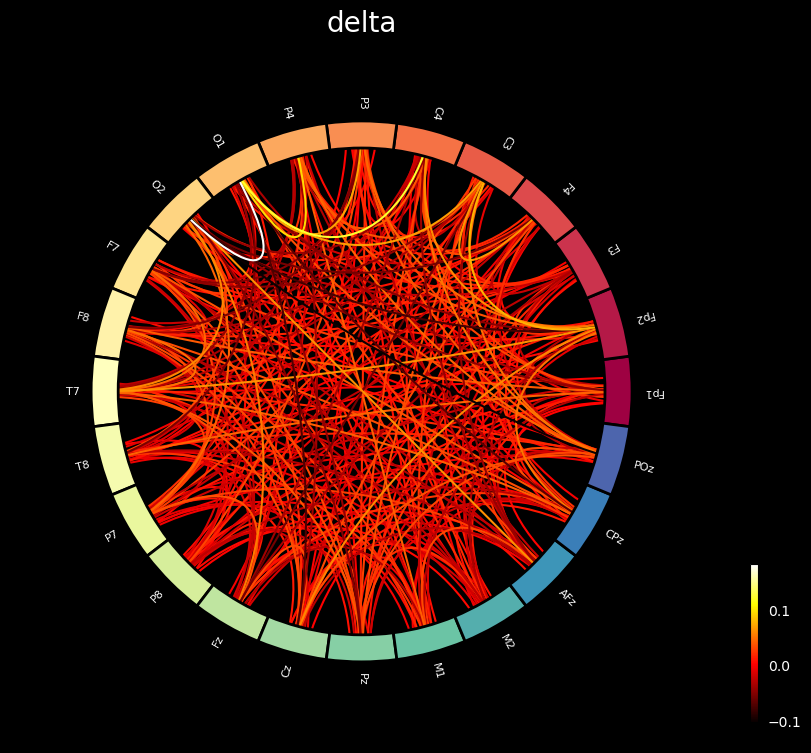

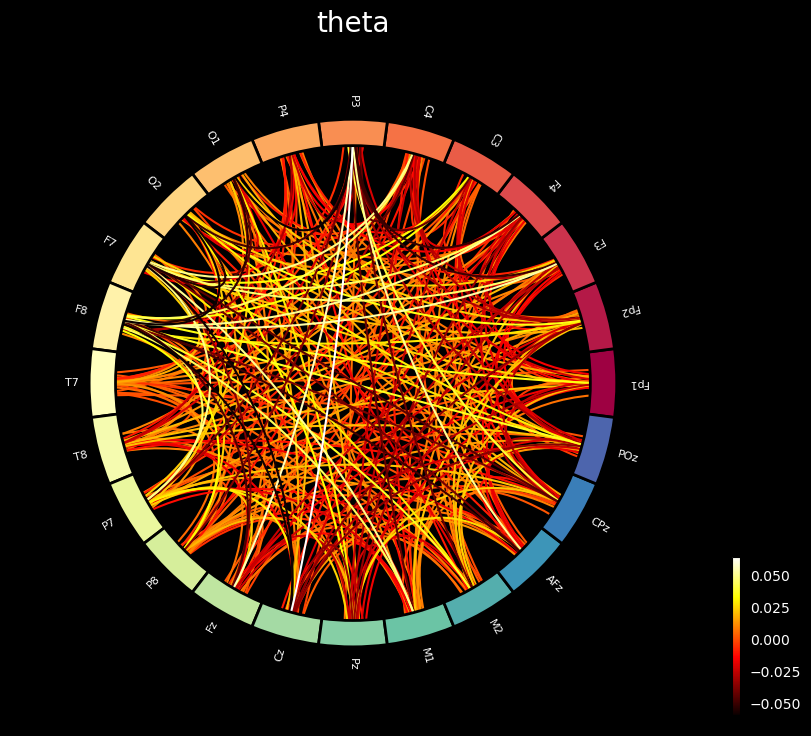

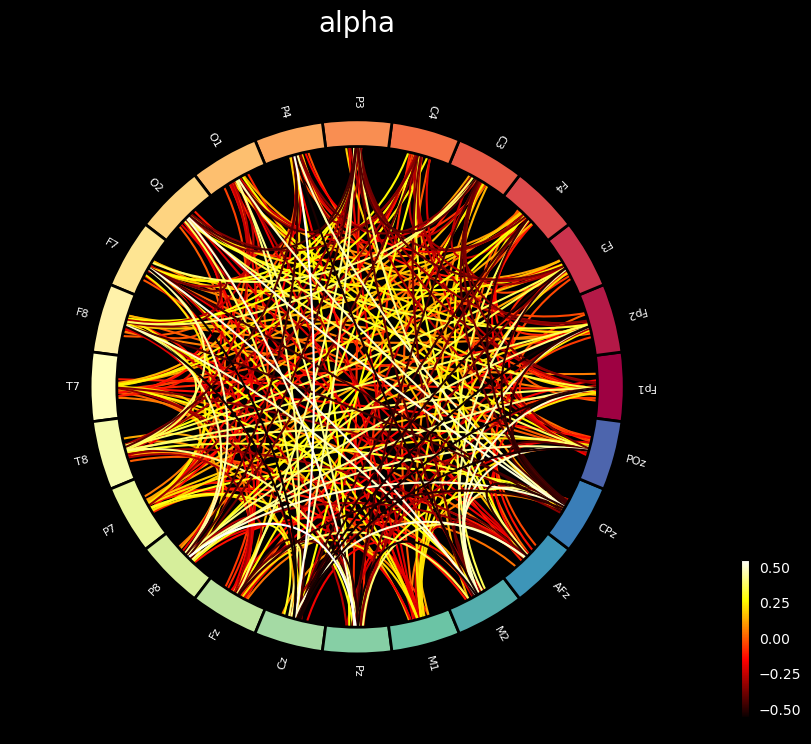

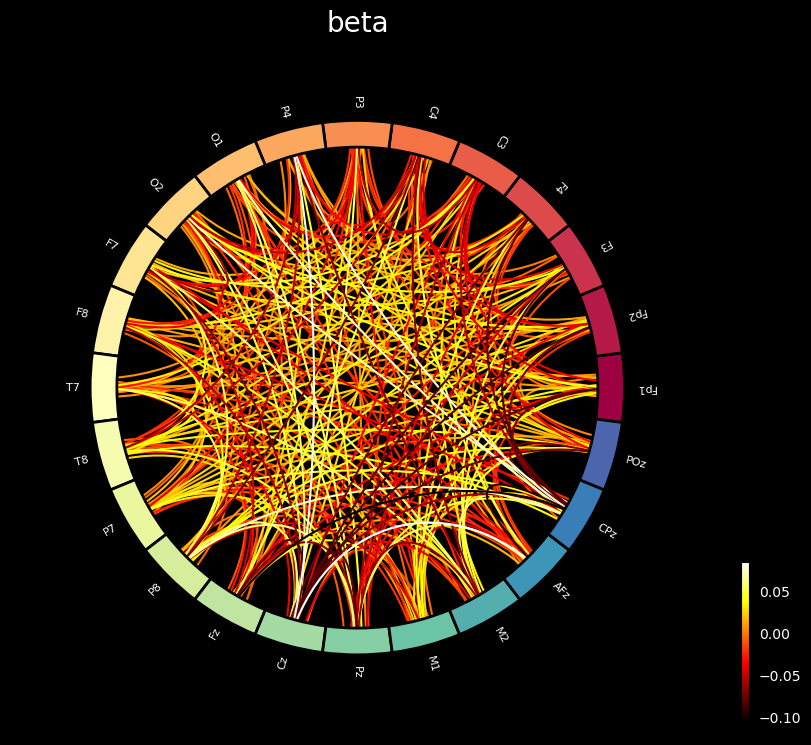

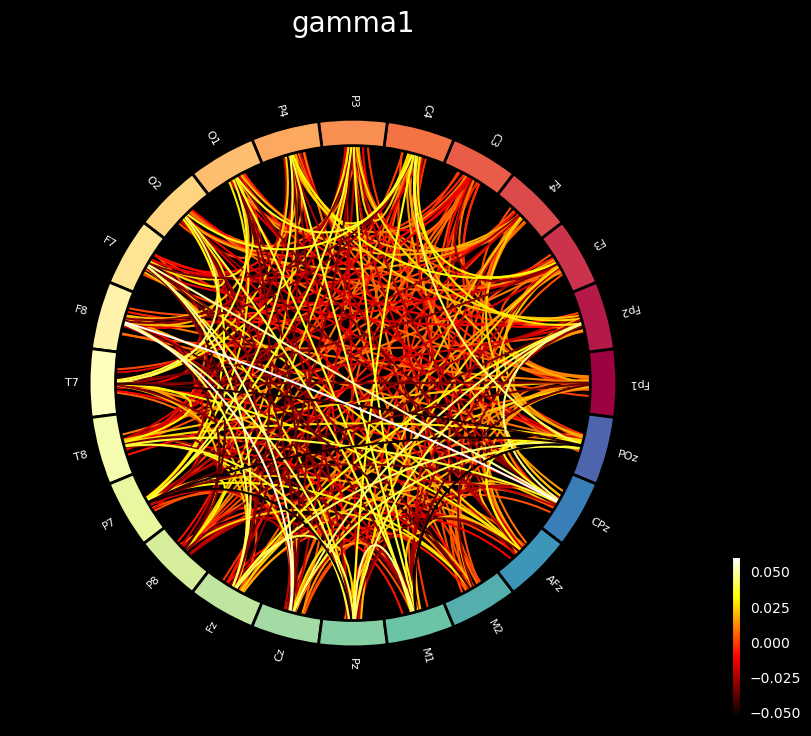

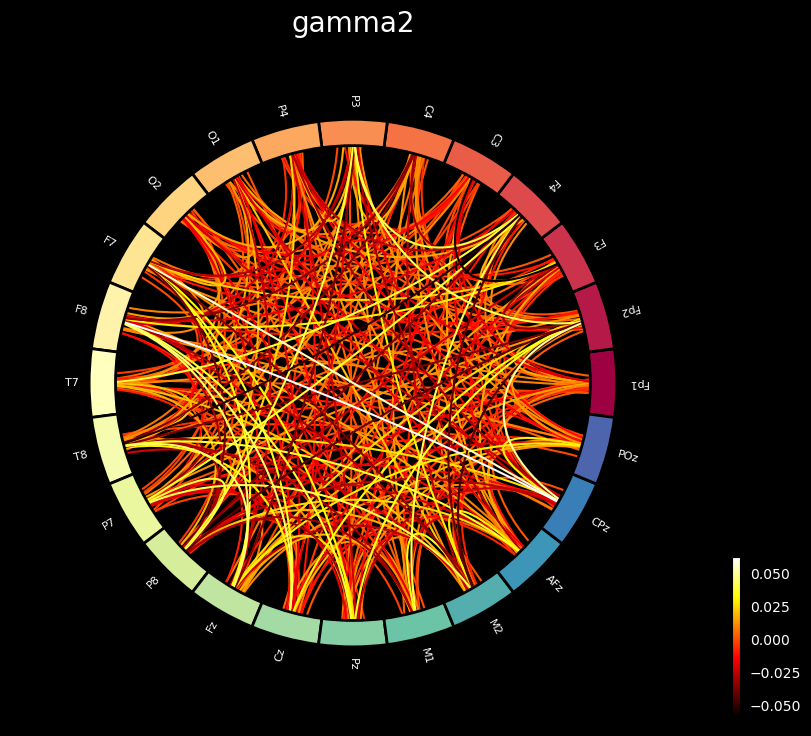

In [51]:
from mne_connectivity.viz import plot_connectivity_circle

# fig, axes = plt.subplots( 1, 6, figsize = ( 200, 100 ), facecolor = "black", subplot_kw=dict(polar=True) )

for band in channel_coherence['S01']:
    conn = np.squeeze( channel_coherence['S01'][band].get_data( output='dense' ) )
    plot_connectivity_circle( conn, 
                             eeg_data['S01'].ch_names,
                             n_lines = 300,
                             title = band,
                             fontsize_title = 20,
                             padding = 3,
                             fontsize_colorbar = 10,
                             )


Nonlinear metrics: Spectral Entropy

In [49]:
def spectral_entropy( psd ):
    psd_norm = psd / np.sum( psd )
    psd_norm[psd_norm == 0] = np.finfo( float ).eps
    return -np.sum( psd_norm * np.log2( psd_norm ) )

In [61]:
# compute pre dmt entropy per band
entropy_pre_alpha = pre_alpha.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
entropy_pre_beta = pre_beta.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
entropy_pre_delta = pre_delta.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
entropy_pre_gamma1 = pre_gamma1.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
entropy_pre_gamma2 = pre_gamma2.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
entropy_pre_theta = pre_theta.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
# compute dmt entropy per band
entropy_dmt_alpha = dmt_alpha.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
entropy_dmt_beta = dmt_beta.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
entropy_dmt_delta = dmt_delta.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
entropy_dmt_gamma1 = dmt_gamma1.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
entropy_dmt_gamma2 = dmt_gamma2.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )
entropy_dmt_theta = dmt_theta.apply( spectral_entropy, axis = 1 ).to_numpy().reshape( -1, 1 )